# Volatility — why did the risk model fail?

**The brief.** The NASDAQ book is run off a **two-year rolling standard deviation**: each
day's 99% value-at-risk is that window's volatility times the normal 1% quantile. Over
fifty years the model has been breached far more often than it promised, and the breaches
did not arrive evenly. The board wants to know what went wrong and what replaces it.

The series is the **NASDAQ Composite**, daily, 1971 to today — three times the span of
the index used in the lecture, and it contains the 1987 crash, the dot-com boom and bust,
the financial crisis and COVID.

Each task is small. Do them in order; later cells use names defined earlier.

> Data: `NASDAQCOM.csv`, loaded straight from the web so this runs in Colab.

---
## Setup — run this and look at the picture

Done for you. Run it, then we discuss what is on the screen before anyone writes code.
Your own work starts at Task 1.

*(The `pip install` is only needed on Colab; it is a no-op if `arch` is already there.)*

In [1]:
!pip install arch -q

1971-02-08 to 2026-09-04,  T = 14013
daily sd 1.275%  ->  20.2% annualized
kurtosis 12.4   skewness -0.32
worst day -13.15% on 2020-03-16;  best day +13.25% on 2001-01-03


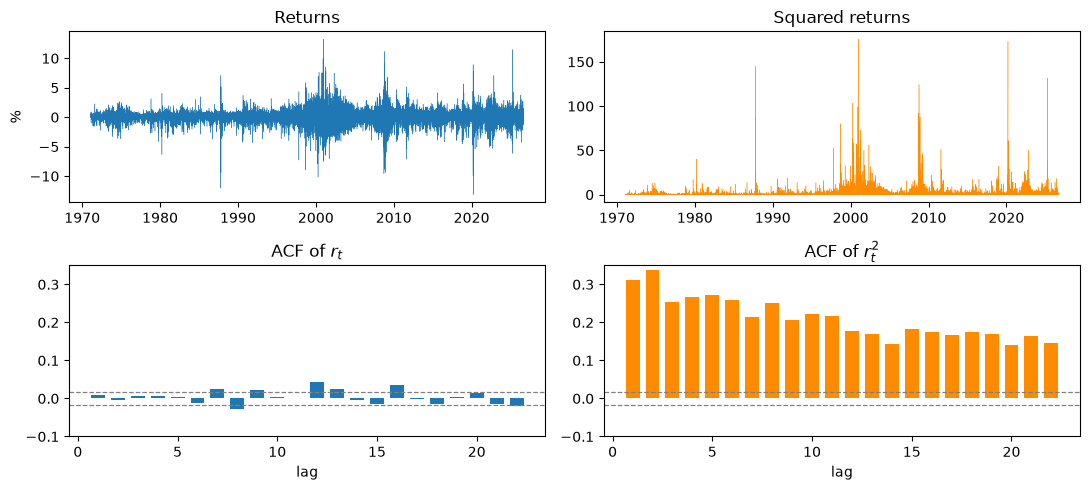

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

import warnings; warnings.simplefilter("ignore")

URL = "https://bashtage.github.io/summer-school/"

# NASDAQ Composite. FRED stores market holidays as ".", so coerce before differencing.
raw = pd.read_csv(URL + "NASDAQCOM.csv")
px = pd.Series(pd.to_numeric(raw["NASDAQCOM"], errors="coerce").to_numpy(),
               index=pd.to_datetime(raw["date"].astype(str), format="%Y%m%d")).dropna()
r = (100 * np.log(px).diff()).dropna()
r.name = "NASDAQ"
T = len(r)

print(f"{r.index[0]:%Y-%m-%d} to {r.index[-1]:%Y-%m-%d},  T = {T}")
print(f"daily sd {r.std():.3f}%  ->  {r.std()*np.sqrt(252):.1f}% annualized")
print(f"kurtosis {stats.kurtosis(r, fisher=False):.1f}   skewness {stats.skew(r):+.2f}")
print(f"worst day {r.min():+.2f}% on {r.idxmin():%Y-%m-%d};  "
      f"best day {r.max():+.2f}% on {r.idxmax():%Y-%m-%d}")

fig, axes = plt.subplots(2, 2, figsize=(11, 5))
axes[0, 0].plot(r.index, r, lw=0.3); axes[0, 0].set_title("Returns"); axes[0, 0].set_ylabel("%")
axes[0, 1].plot(r.index, r**2, lw=0.3, color="darkorange"); axes[0, 1].set_title("Squared returns")
band = 1.96 / np.sqrt(T)
for ax, v, ttl, col in [(axes[1, 0], acf(r, nlags=22, fft=True)[1:], "ACF of $r_t$", "tab:blue"),
                        (axes[1, 1], acf(r**2, nlags=22, fft=True)[1:], "ACF of $r_t^2$", "darkorange")]:
    ax.bar(range(1, 23), v, color=col, width=0.7)
    ax.axhline(band, color="0.5", ls="--", lw=0.9); ax.axhline(-band, color="0.5", ls="--", lw=0.9)
    ax.set_title(ttl); ax.set_xlabel("lag"); ax.set_ylim(-0.1, 0.35)
fig.tight_layout(); plt.show()

**Look at the four panels.** Which of them shows something predictable, and which does
not? Note the date of the best single day — where does it sit relative to the worst?

---
# Step 1 — Reproduce the failure

## Task 1 — Build the model that is in production and count its breaches

Each day, take the standard deviation of the **previous 504 trading days** and set
$\widehat{\mathrm{VaR}}_t = -(\hat\mu + \hat\sigma_{504,t}\,\Phi^{-1}(0.01))$. A breach is
a day whose return falls below $-\widehat{\mathrm{VaR}}_t$.

**Key functions**

- `r.rolling(504).std().shift(1)` — the `.shift(1)` is what stops the window seeing today
- `stats.norm.ppf(0.01)`
- `pd.concat([...], axis=1).dropna()` to line the return up with its VaR
- a boolean Series `.sum()` counts and `.mean()` gives the rate

In [ ]:
# Build the rolling standard deviation, lagged one day, and the VaR from it.


# Line up returns and VaR, drop the warm-up, and build the hit indicator `hit`.


# Print: how many days, breaches, breach rate, and how many were expected.

---
## Task 2 — Were the breaches spread out, or did they arrive together?

A model can be wrong *on average* — too many breaches — or wrong *when it matters*, with
the breaches bunched into a few weeks. These are different failures and only one of them
threatens the firm.

Find the worst 21-day window, and count breaches in three crises.

**Key functions**

- `hit.rolling(21).sum()` — then `.max()` and `.idxmax()`
- slice a date range with `hit.loc["2000-01-01":"2002-12-31"]`
- expected count over any window is `0.01 * len(window)`

In [ ]:
# Worst 21-day run of breaches, and the month it ended.


# For the dot-com bust (2000-01 to 2002-12), the GFC (2008-01 to 2009-06) and
# COVID (2020-01 to 2020-06): breaches against expected.

**Two failures, not one.** Say which of the two you have just demonstrated, and which of
them would actually cost the firm money.

---
# Step 2 — Diagnose it

## Task 3 — Test formally for ARCH

The picture suggests the variance moves. Test it: regress $\hat\epsilon_t^2$ on its own
lags and look at $TR^2$, which is $\chi^2_P$ under the null of no ARCH.

**Key functions**

- demean the returns, then square
- build lags with `.shift(i)` for `i` in 1..5, `sm.add_constant`, `.dropna()`
- `sm.OLS(y, X).fit()` exposes `.rsquared`; the statistic is `nobs * rsquared`
- `stats.chi2.sf(stat, 5)` for the p-value

In [ ]:
# Regress squared demeaned returns on five own lags; report T*R^2 and its p-value.

---
## Task 4 — Fit a GARCH(1,1), and look at both sets of standard errors

Fit the workhorse model. Then print the parameters with **robust** standard errors and
again with the naive ones the likelihood would give you if the innovations really were
normal.

**Key functions**

- `arch_model(r, mean="Constant", p=1, q=1)` then `.fit(disp="off")`
- fit a second time with `cov_type="classic"` for the naive errors
- `.params` and `.std_err` are both Series indexed by parameter name

In [ ]:
# Fit GARCH(1,1) twice: default (robust) and cov_type="classic" (naive).


# Print each parameter with both standard errors side by side.

**Which standard error would you report, and what happens to your $t$-statistics if you
pick the wrong one?** The normal likelihood is wrong here and we know it — that is what
makes this quasi-maximum likelihood rather than maximum likelihood.

---
## Task 5 — How long does a shock last?

Report the persistence of the GARCH(1,1) and turn it into a half-life in trading days.

**Key functions**

- persistence is $\hat\alpha_1 + \hat\beta_1$; index `.params` with `"alpha[1]"`, `"beta[1]"`
- half-life is $\ln(0.5)/\ln(\alpha_1+\beta_1)$
- the long-run variance is $\omega/(1-\alpha_1-\beta_1)$; annualize its square root with
  $\sqrt{252}$

In [ ]:
# Print persistence, the half-life in trading days, and the annualized long-run volatility.

---
# Step 3 — Does the sign of the shock matter?

## Task 6 — Fit the asymmetric models and compare them

Fit GARCH(1,1), GJR-GARCH, TARCH and EGARCH. For each report the log-likelihood, AIC,
BIC, the asymmetry parameter, and the kurtosis of the standardized residuals.

**Key functions**

- `arch_model(r, p=1, o=1, q=1)` adds the GJR asymmetry term; add `power=1.0` for TARCH
- EGARCH: `from arch.univariate import ConstantMean, EGARCH`, then
  `ConstantMean(r, volatility=EGARCH(p=1, o=1, q=1))`
- `.loglikelihood`, `.aic`, `.bic`, `.params.get("gamma[1]")`, `.std_resid`
- `stats.kurtosis(x, fisher=False)` gives kurtosis on the scale where a normal is 3

In [ ]:
# Fit the four models and print a comparison table.

---
## Task 7 — Is the asymmetry real, and does the model actually fit?

Two checks on the GJR model. First, a $t$-statistic on $\hat\gamma_1$ using robust
standard errors — **not** a likelihood ratio test, which is invalid under QMLE. Second,
Ljung–Box on the **squared** standardized residuals, with the degrees of freedom adjusted
for the estimated variance parameters.

**Key functions**

- `f.params["gamma[1]"] / f.std_err["gamma[1]"]`
- `acorr_ljungbox(z**2, lags=[10], return_df=True)["lb_stat"].iloc[0]`
- adjust by hand: `stats.chi2.sf(stat, 10 - k)` where `k` is the number of variance
  parameters (2 for GARCH, 3 for the other three)

In [ ]:
# t-statistic on the GJR asymmetry parameter, using robust standard errors.


# For each of the four models, the Ljung-Box p-value on squared standardized
# residuals at 10 lags, with the degrees of freedom adjusted.

**Careful here.** Compare the model the information criteria prefer against the one that
survives the diagnostic. If they are not the same model, which do you take to the board,
and why?

---
# Step 4 — Would the replacement have helped?

## Task 8 — Rebuild the VaR on the GJR variance and re-count

Same 1% normal quantile, same data — only the variance changes, from a two-year average
to the GJR conditional variance.

**Key functions**

- `gj.conditional_volatility` is $\hat\sigma_t$, already lagged correctly by construction
- build the VaR exactly as in Task 1, but with that in place of `roll_sd`
- align both VaR series and the returns with `pd.concat(..., axis=1).dropna()`

In [ ]:
# Build the GJR-based VaR, align it with the rolling-window VaR and the returns.


# Print total breaches for both, then the three crisis windows again.

---
## Task 9 — See it

Plot the two VaR paths through one crisis, with the returns behind them, so the
difference in how fast each reacts is visible.

**Key functions**

- slice with `dd.loc["2008-01-01":"2009-06-30"]`
- plot `-sub["flat"]` and `-sub["gjr"]` so both sit on the same scale as the returns
- mark the rolling-window breaches with `ax.plot(dates, values, "o")`

In [ ]:
# Plot returns, both VaR paths and the rolling-window breaches, over the GFC.

---
# Write the answer to the brief

Three short paragraphs, using your own numbers.

**1. What went wrong.** Name both failures — the count and the clustering — and say which
of them a wider interval would fix. Explain *why* a two-year average is always too small
at the start of a crisis.

**2. What replaces it.** Name the model, and justify the choice against the alternatives
you fitted. If the criteria and the diagnostic disagreed, say how you resolved it.

**3. What it does not fix.** Compare your new breach count against what was expected.
The variance is now right; something else is still wrong. What, and where would you go
next?